### **[Simulated 2 Long Term Investing Strategies Using 20 years of Market Data](https://wire.insiderfinance.io/i-simulated-2-long-term-investing-strategies-using-20-years-of-market-data-to-see-which-one-fc1a5a0b48f7)**

- Buy and Hold Strategy
- Dollar Cost Averaging Strategy

##### **Install Libraries**

In [1]:
!pip install -qq yfinance pandas numpy matplotlib scipy

##### **Import Libraries**

In [2]:
import sys

import warnings
warnings.filterwarnings("ignore")

from datetime import datetime
from IPython.display import display

import numpy as np
import pandas as pd
import yfinance as yf

import matplotlib.pyplot as plt

from scipy.stats import norm

IN_COLAB = 'google.colab' in sys.modules

# Make plots look cleaner
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (15, 8)
plt.rcParams["font.size"] = 10

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.precision", 2)

%autosave 20

Autosaving every 20 seconds


##### **Portfolio Configuration**

In [3]:
# Diversified portfolio (US equities)
tickers = [
  "AAPL",   # Technology
  "MSFT",   # Technology
  "JNJ",    # Healthcare
  "JPM",    # Financials
  "KO"      # Consumer Staples
]

# Backtest period
start_date = "2005-01-01"
end_date = datetime.today().strftime("%Y-%m-%d")

# Monthly investment amount (DCA)
monthly_investment = 1000  # USD

# Initial lump sum for Buy and Hold
initial_investment = monthly_investment

print("Portfolio")
print("-" * 40)
for ticker in tickers:
  print(f"• {ticker}")

print(f"\nMonthly Investment : ${monthly_investment:,}")
print(f"Backtest Period    : {start_date} to {end_date}")

Portfolio
----------------------------------------
• AAPL
• MSFT
• JNJ
• JPM
• KO

Monthly Investment : $1,000
Backtest Period    : 2005-01-01 to 2026-07-16


In [4]:
prices = (
  yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
  )["Close"]
  .dropna()
)

print(f"Downloaded {len(prices)} trading days.")
display(prices.head(5))

Downloaded 5416 trading days.


Ticker,AAPL,JNJ,JPM,KO,MSFT
Date,,,,,
2005-01-03,0.95,34.15,22.06,10.87,18.34
2005-01-04,0.96,34.05,21.83,10.72,18.41
2005-01-05,0.97,34.02,21.87,10.67,18.37
2005-01-06,0.97,34.12,22.00,10.76,18.35
2005-01-07,1.04,34.00,21.82,10.77,18.29


##### **Creating the Investment Schedule**

In [5]:
# First trading day of each month
investment_dates = (
  prices
  .groupby(pd.Grouper(freq="MS"))
  .apply(lambda x: x.index[0])
)

investment_dates = pd.DatetimeIndex(investment_dates)

print(f"Total monthly investments: {len(investment_dates)}")
print(investment_dates[:10])

Total monthly investments: 259
DatetimeIndex(['2005-01-03', '2005-02-01', '2005-03-01', '2005-04-01', '2005-05-02', '2005-06-01', '2005-07-01', '2005-08-01', '2005-09-01', '2005-10-03'], dtype='datetime64[ns]', freq=None)


##### **Simulating Dollar Cost Averaging**

In [6]:
allocation = 1 / len(tickers)

shares_owned = pd.Series(0.0, index=tickers)

portfolio_value = []
cash_invested = []

total_contributions = 0

for current_date in prices.index:
  # Invest on scheduled dates
  if current_date in investment_dates:
    investment_per_stock = monthly_investment * allocation

    for ticker in tickers:
      price = prices.loc[current_date, ticker]
      shares_owned[ticker] += investment_per_stock / price

    total_contributions += monthly_investment

  # Current portfolio value
  value = (shares_owned * prices.loc[current_date]).sum()

  portfolio_value.append(value)
  cash_invested.append(total_contributions)

# Create results DataFrame
dca_results = pd.DataFrame({
  "Portfolio Value": portfolio_value,
  "Total Contributions": cash_invested
}, index=prices.index)

dca_results["Profit"] = (
  dca_results["Portfolio Value"]
  - dca_results["Total Contributions"]
)

display(dca_results.head(10))

,Portfolio Value,Total Contributions,Profit
Date,,,
2005-01-03,1000.00,1000,0.00
2005-01-04,997.31,1000,-2.69
2005-01-05,998.00,1000,-2.00
2005-01-06,1001.28,1000,1.28
2005-01-07,1013.45,1000,13.45
2005-01-10,1015.50,1000,15.50
2005-01-11,997.36,1000,-2.64
2005-01-12,1002.44,1000,2.44
2005-01-13,1004.89,1000,4.89


##### **Simulating Buy and Hold**

In [7]:
# Total amount that DCA invested
total_investment = monthly_investment * len(investment_dates)

# Equal allocation across all stocks
allocation = 1 / len(tickers)

# First trading day
first_day = prices.index[0]

# Purchase shares on day one
buy_hold_shares = pd.Series(index=tickers, dtype=float)

for ticker in tickers:
  allocation_amount = total_investment * allocation
  buy_hold_shares[ticker] = allocation_amount / prices.loc[first_day, ticker]

# Portfolio value through time
buy_hold_value = []

for date in prices.index:
  value = (buy_hold_shares * prices.loc[date]).sum()
  buy_hold_value.append(value)

buy_hold_results = pd.DataFrame({
  "Portfolio Value": buy_hold_value
}, index=prices.index)

buy_hold_results["Total Contributions"] = total_investment
buy_hold_results["Profit"] = (
  buy_hold_results["Portfolio Value"]
  - buy_hold_results["Total Contributions"]
)

display(buy_hold_results.head())

,Portfolio Value,Total Contributions,Profit
Date,,,
2005-01-03,259000.00,259000,0.00
2005-01-04,258303.84,259000,-696.16
2005-01-05,258482.90,259000,-517.10
2005-01-06,259331.55,259000,331.55
2005-01-07,262482.45,259000,3482.45


In [8]:
print(f"Total DCA Contributions : ${dca_results['Total Contributions'].iloc[-1]:,.2f}")
print(f"Total Buy & Hold Investment : ${total_investment:,.2f}")

Total DCA Contributions : $259,000.00
Total Buy & Hold Investment : $259,000.00


##### **Calculating Performance Metrics**

In [9]:
RISK_FREE_RATE = 0.04  # 4% annual risk-free rate

def calculate_max_drawdown(portfolio_values):
  """
  Calculate the maximum drawdown.
  """
  running_max = portfolio_values.cummax()
  drawdown = (portfolio_values - running_max) / running_max
  return drawdown.min(), drawdown


def calculate_metrics(results, risk_free_rate=RISK_FREE_RATE):
  """
  Calculate common portfolio performance metrics.
  """

  portfolio = results["Portfolio Value"]
  daily_returns = portfolio.pct_change().dropna()

  total_return = (
    portfolio.iloc[-1] / results["Total Contributions"].iloc[-1]
  ) - 1
  years = (portfolio.index[-1] - portfolio.index[0]).days / 365.25

  cagr = (
    portfolio.iloc[-1] / results["Total Contributions"].iloc[-1]
  ) ** (1 / years) - 1
  annual_volatility = daily_returns.std() * np.sqrt(252)

  sharpe_ratio = (
    daily_returns.mean() * 252 - risk_free_rate
  ) / annual_volatility
  downside_returns = daily_returns[daily_returns < 0]

  sortino_ratio = (
    daily_returns.mean() * 252 - risk_free_rate
  ) / (downside_returns.std() * np.sqrt(252))
  max_drawdown, drawdown_series = calculate_max_drawdown(portfolio)

  calmar_ratio = cagr / abs(max_drawdown)

  metrics = pd.Series({
    "Final Portfolio Value": portfolio.iloc[-1],
    "Total Contributions": results["Total Contributions"].iloc[-1],
    "Total Return": total_return,
    "CAGR": cagr,
    "Annual Volatility": annual_volatility,
    "Sharpe Ratio": sharpe_ratio,
    "Sortino Ratio": sortino_ratio,
    "Maximum Drawdown": max_drawdown,
    "Calmar Ratio": calmar_ratio
  })

  return metrics, drawdown_series

In [10]:
dca_metrics, dca_drawdown = calculate_metrics(dca_results)

buy_hold_metrics, buy_hold_drawdown = calculate_metrics(
  buy_hold_results
)

comparison = pd.DataFrame({
  "Dollar Cost Averaging": dca_metrics,
  "Buy and Hold": buy_hold_metrics
})

display(comparison)

,Dollar Cost Averaging,Buy and Hold
Final Portfolio Value,3421398.69,20607907.31
Total Contributions,259000.00,259000.00
Total Return,12.21,78.57
CAGR,0.13,0.23
Annual Volatility,0.34,0.25
Sharpe Ratio,1.13,0.78
Sortino Ratio,2.38,1.06
Maximum Drawdown,-0.37,-0.53
Calmar Ratio,0.35,0.43


##### **Portfolio Equity Curve**

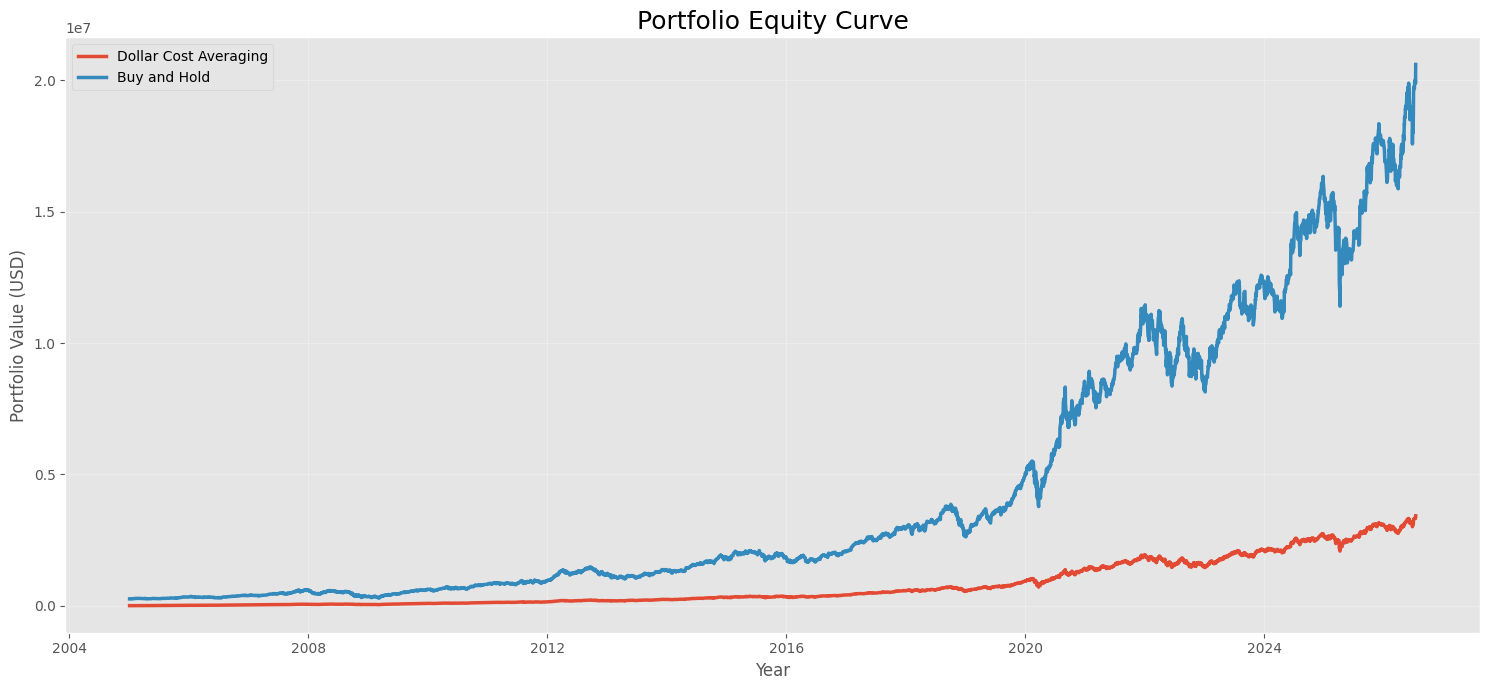

In [11]:
plt.figure(figsize=(15,7))

plt.plot(
  dca_results.index,
  dca_results["Portfolio Value"],
  linewidth=2.5,
  label="Dollar Cost Averaging"
)

plt.plot(
  buy_hold_results.index,
  buy_hold_results["Portfolio Value"],
  linewidth=2.5,
  label="Buy and Hold"
)

plt.title("Portfolio Equity Curve", fontsize=18)
plt.xlabel("Year")
plt.ylabel("Portfolio Value (USD)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
if not IN_COLAB:
  plt.savefig("portfolio_equity_curve.png", dpi=300)
plt.show()

##### **Portfolio Profit**

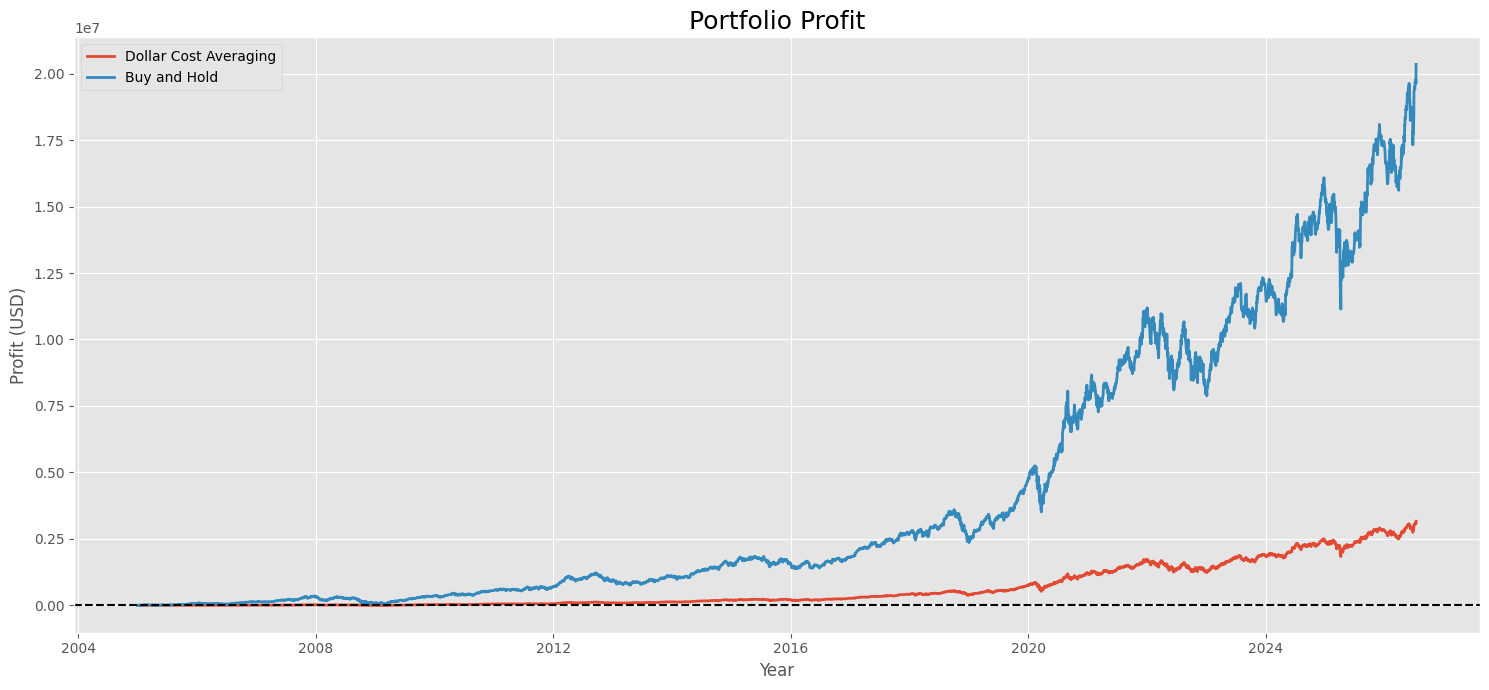

In [12]:
plt.figure(figsize=(15,7))

plt.plot(
  dca_results.index,
  dca_results["Profit"],
  linewidth=2,
  label="Dollar Cost Averaging"
)

plt.plot(
  buy_hold_results.index,
  buy_hold_results["Profit"],
  linewidth=2,
  label="Buy and Hold"
)

plt.axhline(0, color="black", linestyle="--")

plt.title("Portfolio Profit", fontsize=18)
plt.xlabel("Year")
plt.ylabel("Profit (USD)")
plt.legend()

plt.tight_layout()
if not IN_COLAB:
  plt.savefig("portfolio_profit.png", dpi=300)
plt.show()

##### **Total Contributions**

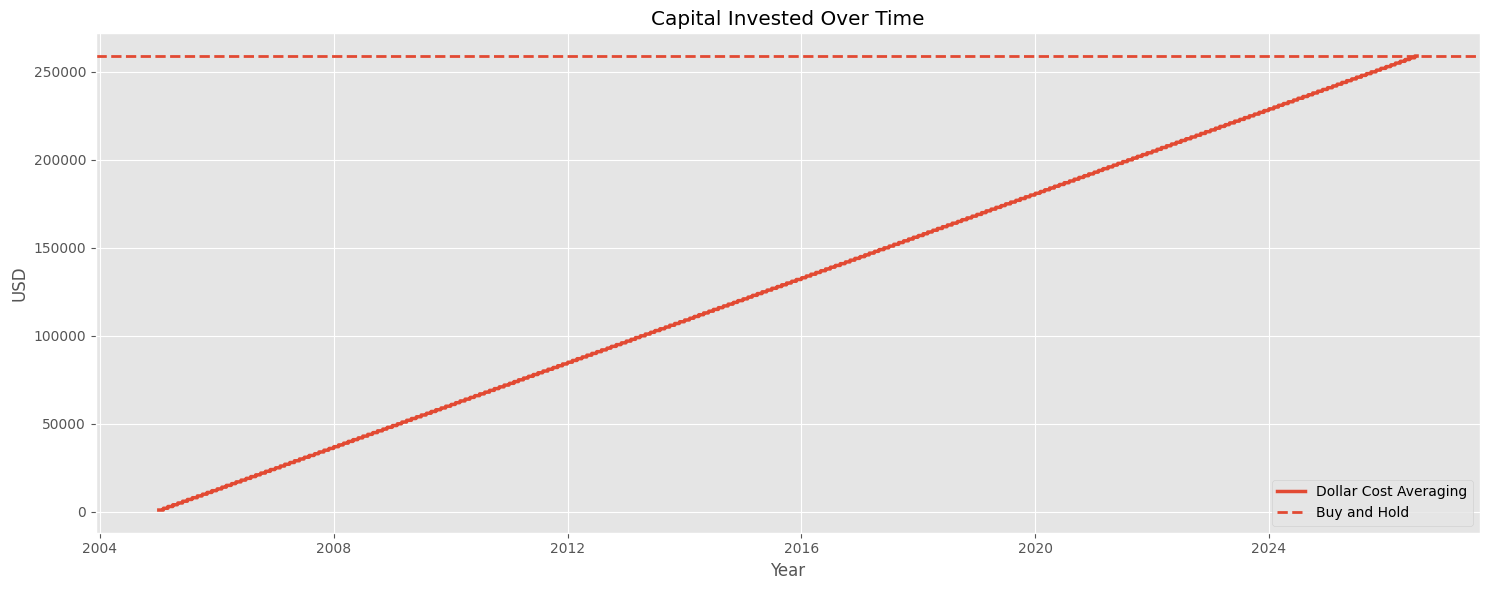

In [13]:
plt.figure(figsize=(15,6))

plt.plot(
  dca_results.index,
  dca_results["Total Contributions"],
  linewidth=2.5,
  label="Dollar Cost Averaging"
)

plt.axhline(
  total_investment,
  linestyle="--",
  linewidth=2,
  label="Buy and Hold"
)

plt.title("Capital Invested Over Time")
plt.xlabel("Year")
plt.ylabel("USD")
plt.legend()

plt.tight_layout()
if not IN_COLAB:
  plt.savefig("total_contributions.png", dpi=300)
plt.show()

##### **Portfolio Drawdown**

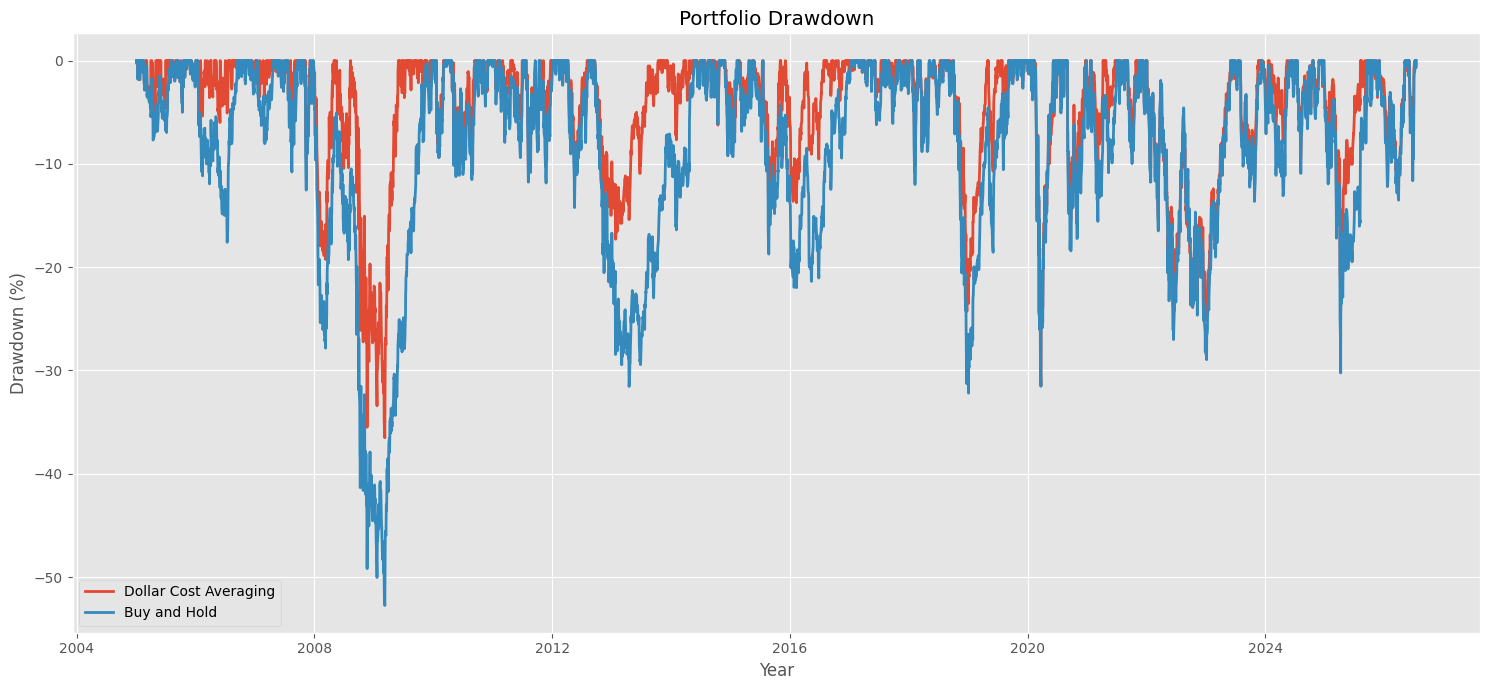

In [14]:
plt.figure(figsize=(15,7))

plt.plot(
  dca_drawdown.index,
  dca_drawdown * 100,
  linewidth=2,
  label="Dollar Cost Averaging"
)

plt.plot(
  buy_hold_drawdown.index,
  buy_hold_drawdown * 100,
  linewidth=2,
  label="Buy and Hold"
)

plt.title("Portfolio Drawdown")
plt.xlabel("Year")
plt.ylabel("Drawdown (%)")
plt.legend()

plt.tight_layout()
if not IN_COLAB:
  plt.savefig("drawdown_comparison.png", dpi=300)
plt.show()